# EDA & Visualization: Employee Attrition

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data_preprocess.csv")
df.head()

,age,job_level,tenure_years,salary_usd,salary_vs_market_pct,rto_mandate,days_in_office_required,commute_minutes,prefers_remote,flexibility_importance,...,department_Data,department_Engineering,department_Finance,department_HR,department_Marketing,department_Operations,department_Product,department_Sales,work_arrangement_onsite,work_arrangement_remote
0,26,0,5.5,70000,5.2,0,4,44,1,3,...,False,False,False,False,True,False,False,False,True,False
1,35,0,0.5,64000,-15.5,0,5,48,1,2,...,False,False,False,False,False,False,False,True,True,False
2,23,2,2.0,142000,-15.9,1,3,35,1,3,...,False,False,False,True,False,False,False,False,False,False
3,20,4,2.2,147000,2.6,0,5,16,0,5,...,False,False,False,False,False,False,False,True,True,False
4,40,2,6.0,141000,11.3,1,4,55,1,4,...,True,False,False,False,False,False,False,False,False,False


In [27]:
# ตรวจสอบ Missing Value
print(df.isnull().sum().sum())
df.describe()

0


,age,job_level,tenure_years,salary_usd,salary_vs_market_pct,rto_mandate,days_in_office_required,commute_minutes,prefers_remote,flexibility_importance,...,after_hours_work,burnout_score,manager_relationship_score,manager_1on1_per_month,engagement_score,promotions_last_2y,career_growth_score,recent_layoff_round,team_size,attrition
count,43439.000000,43439.000000,43439.000000,43439.000000,43439.000000,43439.000000,43439.000000,43439.000000,43439.000000,43439.000000,...,43439.000000,43439.000000,43439.000000,43439.000000,43439.000000,43439.000000,43439.000000,43439.000000,43439.000000,43439.000000
mean,34.710352,1.641658,3.440738,115217.677663,-1.950480,0.422869,2.689173,35.642234,0.680379,2.994774,...,0.256751,4.818509,2.995327,1.500472,65.730634,0.451000,3.000990,0.236400,13.463201,0.182578
std,8.316193,1.409371,2.336235,49417.964648,9.992409,0.494021,1.914136,24.494975,0.466335,1.415416,...,0.436846,1.965320,1.416003,1.236202,16.717593,0.623109,1.414726,0.424876,6.367064,0.386325
min,20.000000,0.000000,0.300000,47000.000000,-35.000000,0.000000,0.000000,3.000000,0.000000,1.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,29.000000,1.000000,1.700000,75000.000000,-8.700000,0.000000,0.000000,17.000000,0.000000,2.000000,...,0.000000,3.400000,2.000000,1.000000,54.000000,0.000000,2.000000,0.000000,8.000000,0.000000
50%,34.000000,1.000000,2.900000,103000.000000,-1.900000,0.000000,3.000000,30.000000,1.000000,3.000000,...,0.000000,4.800000,3.000000,1.000000,66.000000,0.000000,3.000000,0.000000,13.000000,0.000000
75%,40.000000,2.000000,4.600000,146000.000000,4.800000,1.000000,4.000000,48.000000,1.000000,4.000000,...,1.000000,6.200000,4.000000,2.000000,77.000000,1.000000,4.000000,0.000000,19.000000,0.000000
max,64.000000,5.000000,11.400000,263620.000000,35.000000,1.000000,5.000000,118.000000,1.000000,5.000000,...,1.000000,10.000000,5.000000,4.000000,100.000000,2.000000,5.000000,1.000000,24.000000,1.000000


### 1. สัดส่วนพนักงานที่ลาออก (Attrition)

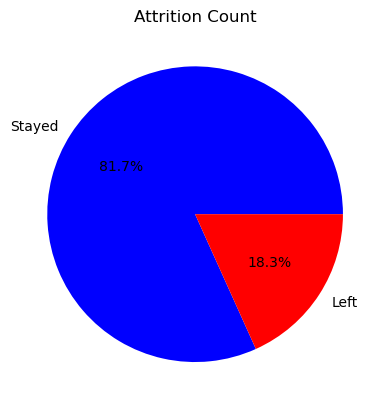

35508
7931


In [28]:
attr_counts = df['attrition'].value_counts().sort_index()
df['attrition'].value_counts().plot(kind='pie', labels=['Stayed','Left'], colors=['blue','red'], autopct='%1.1f%%')
plt.title("Attrition Count")
plt.ylabel('')
plt.show()
print(attr_counts[0])
print(attr_counts[1])

**Insight:** พนักงานส่วนใหญ่ยังอยู่ 35,508 คน (attrition=0)
มีคนลาออก 7,931 คน (attrition=1)
 เป็นส่วนน้อย ข้อมูลจึงไม่สมดุล (imbalanced)

### 2. Age กับ Attrition

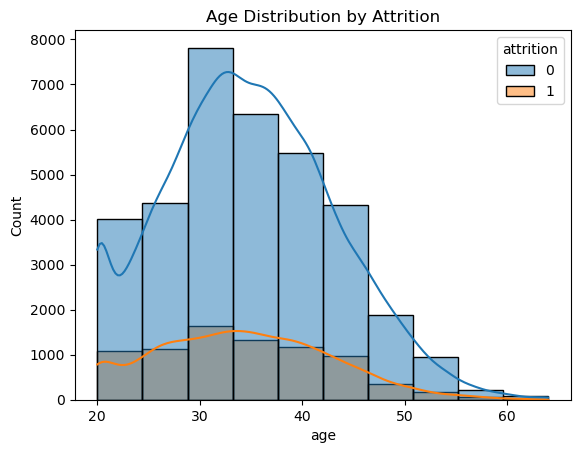

In [29]:
sns.histplot(data=df, x='age', hue='attrition', bins=10, kde=True)
plt.title("Age Distribution by Attrition")
plt.show()

**Insight:** การกระจายอายุของคนที่ลาออกกับคนที่อยู่ต่อคล้ายกัน อายุไม่ใช่ปัจจัยหลักที่แยกสองกลุ่มนี้ได้ชัดเจน

### 3. Burnout Score กับ Attrition

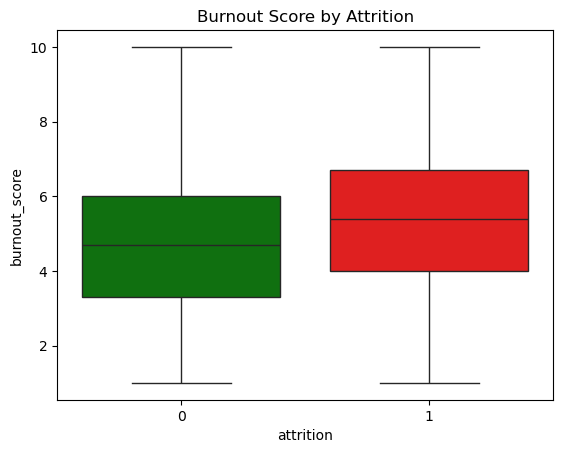

In [30]:
sns.boxplot(x='attrition', y='burnout_score', data=df, hue='attrition', palette=['green','red'], legend=False)
plt.title("Burnout Score by Attrition")
plt.show()

**Insight:** กลุ่มที่ลาออก (attrition=1) มีค่า burnout_score สูงกว่ากลุ่มที่อยู่ต่ออย่างเห็นได้ชัด แสดงว่ายิ่งหมดไฟ ยิ่งมีโอกาสลาออกสูง

### 4. Engagement Score (Job Satisfaction) กับ Attrition

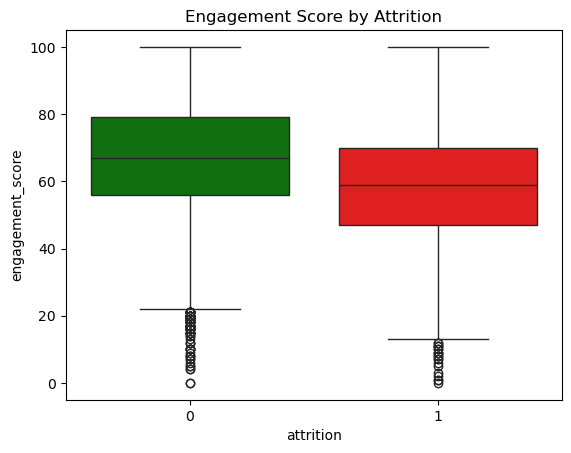

In [31]:
sns.boxplot(x='attrition', y='engagement_score', data=df, hue='attrition', palette=['green','red'], legend=False)
plt.title("Engagement Score by Attrition")
plt.show()

**Insight:** กลุ่มที่ลาออกมี engagement_score ต่ำกว่ากลุ่มที่อยู่ต่อชัดเจน ความพึงพอใจ/ความผูกพันกับงานต่ำ สัมพันธ์กับการลาออกสูง

### 5. Work Arrangement (Onsite) กับ Attrition

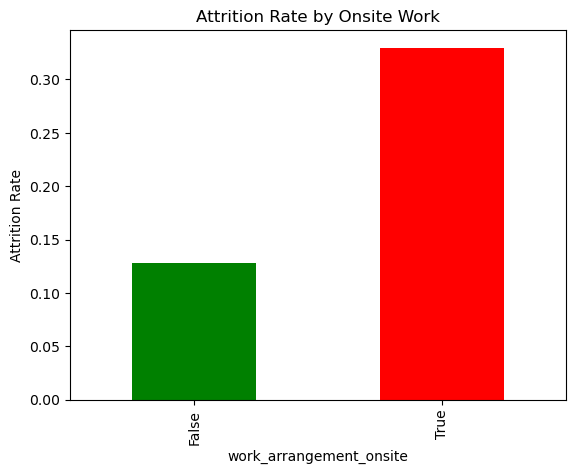

In [32]:
df.groupby('work_arrangement_onsite')['attrition'].mean().plot(kind='bar', color=['green','red'])
plt.title("Attrition Rate by Onsite Work")
plt.ylabel("Attrition Rate")
plt.show()

**Insight:** พนักงานที่ทำงาน onsite (work_arrangement_onsite=1) มีอัตราการลาออกสูงกว่าคนที่ไม่ได้ทำงาน onsite (hybrid/remote) อย่างชัดเจน

### 6. Years at Company (Tenure) กับ Attrition

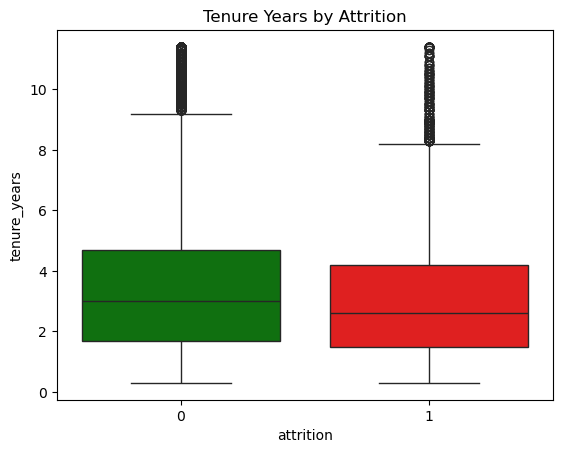

In [33]:
sns.boxplot(x='attrition', y='tenure_years', data=df, hue='attrition', palette=['green','red'], legend=False)
plt.title("Tenure Years by Attrition")
plt.show()

**Insight:** กลุ่มที่ลาออกมีอายุงาน (tenure_years) น้อยกว่ากลุ่มที่อยู่ต่อ พนักงานใหม่มีแนวโน้มลาออกมากกว่าพนักงานที่อยู่มานาน

### 7. Correlation Heatmap

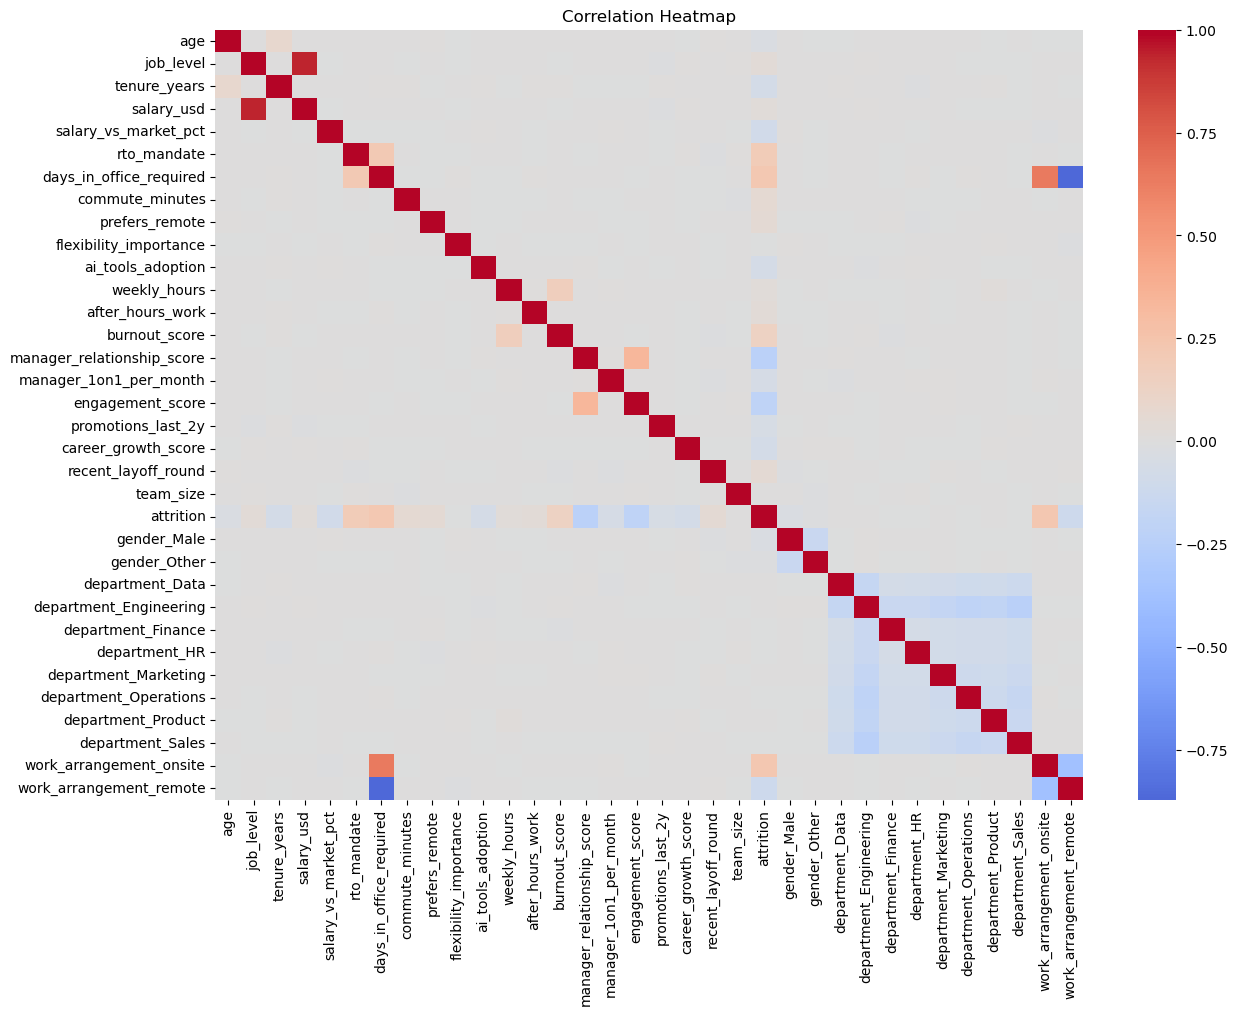

In [34]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

**Insight:** ดูจาก heatmap ปัจจัยที่มีสีเข้ม (บวก/ลบ) กับแถว/คอลัมน์ attrition มากที่สุด ได้แก่ days_in_office_required, manager_relationship_score, engagement_score, rto_mandate และ burnout_score สอดคล้องกับกราฟที่ทำไปด้านบน